In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [3]:
FILE_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(FILE_PATH)

print("\nDataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())


Dataset shape: (7043, 21)

First five rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Str

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
df["Churn"].value_counts(normalize=True).round(4)

Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64

/tmp/ipykernel_16/2026941232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


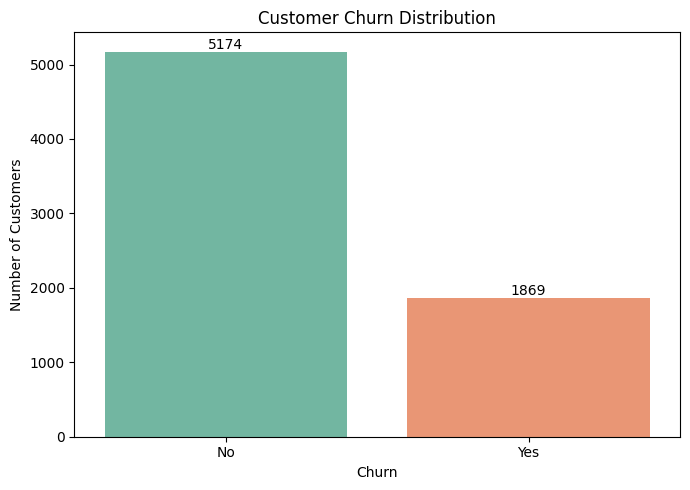

In [7]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    order=["No", "Yes"],
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


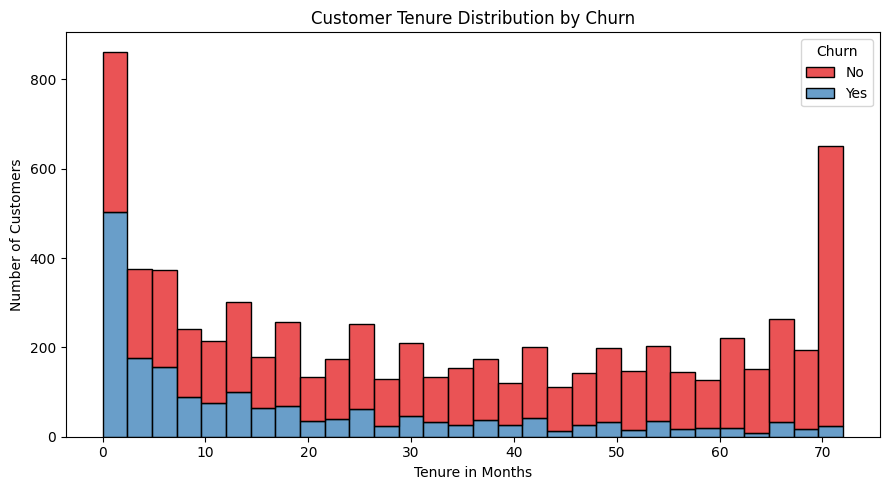

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack",
    palette="Set1"
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/4227218938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


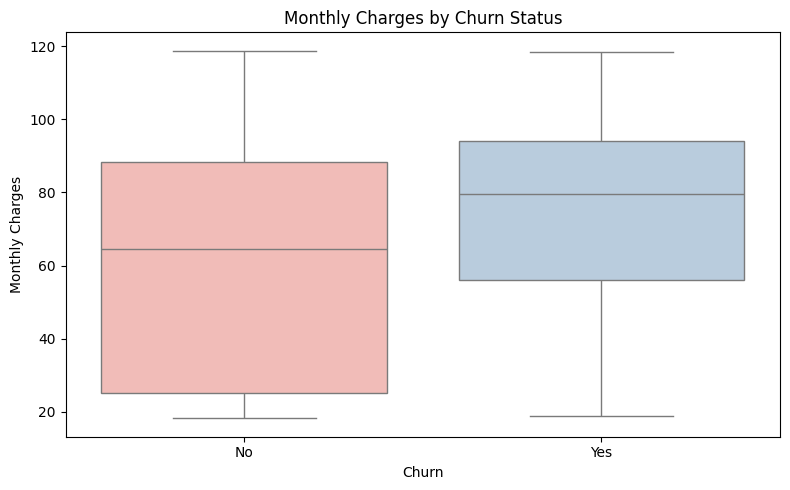

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    order=["No", "Yes"],
    palette="Pastel1"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()


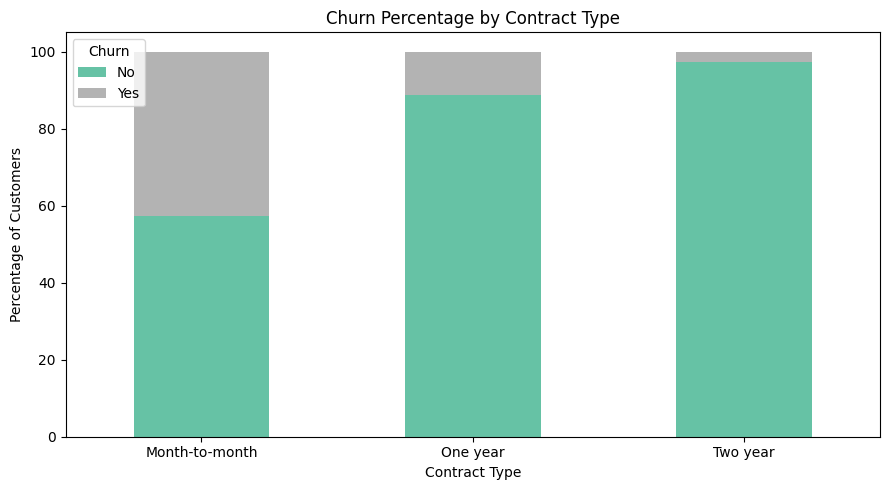

In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.reindex(
    ["Month-to-month", "One year", "Two year"]
)

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    colormap="Set2"
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [11]:
data = df.copy()

# Remove leading and trailing spaces from column names
data.columns = data.columns.str.strip()

# Customer ID is an identifier and does not help predict churn
if "customerID" in data.columns:
    data.drop(columns=["customerID"], inplace=True)

# TotalCharges may contain blank strings and may be read as object
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

In [12]:
data.isnull().sum()[data.isnull().sum() > 0]

TotalCharges    11
dtype: int64

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})


In [15]:
data.dropna(subset=["Churn"], inplace=True)

In [16]:
data["Churn"] = data["Churn"].astype(int)

In [17]:
data["Churn"].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

In [18]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

numerical_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


In [19]:
numerical_columns

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [20]:
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [22]:
X_train.shape

(5616, 19)

In [23]:
X_test.shape

(1405, 19)

In [24]:
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            MinMaxScaler()
        )
    ]
)

In [25]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)


In [27]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Support Vector Machine": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}

In [28]:
results = []
trained_models = {}

for model_name, classifier in models.items():

    print("\n" + "=" * 65)
    print(f"Training: {model_name}")
    print("=" * 65)

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    # Train model
    model_pipeline.fit(X_train, y_train)

    # Store trained pipeline
    trained_models[model_name] = model_pipeline

    # Generate predictions
    y_pred = model_pipeline.predict(X_test)

    # Generate probabilities for ROC-AUC
    if hasattr(model_pipeline, "predict_proba"):
        y_probability = model_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_probability = None

    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if y_probability is not None:
        roc_auc = roc_auc_score(y_test, y_probability)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )




Training: Logistic Regression

Classification report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.77      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.79      0.74      0.75      1405


Training: Naive Bayes

Classification report:
              precision    recall  f1-score   support

    No Churn       0.90      0.68      0.77      1033
       Churn       0.47      0.79      0.59       372

    accuracy                           0.71      1405
   macro avg       0.69      0.74      0.68      1405
weighted avg       0.79      0.71      0.72      1405


Training: Support Vector Machine

Classification report:
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.51      0.76      0.61       372

    accuracy          

In [29]:
metrics_df = pd.DataFrame(results)

# Sort primarily by F1-score because churn is an imbalanced target
metrics_df = metrics_df.sort_values(
    by=["F1-score", "Recall", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

print(
    metrics_df.round(4).to_string(index=False)
)



MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Support Vector Machine    0.7445     0.5118  0.7608    0.6119   0.8198
   Logistic Regression    0.7402     0.5062  0.7688    0.6105   0.8391
           Naive Bayes    0.7082     0.4697  0.7930    0.5900   0.8079


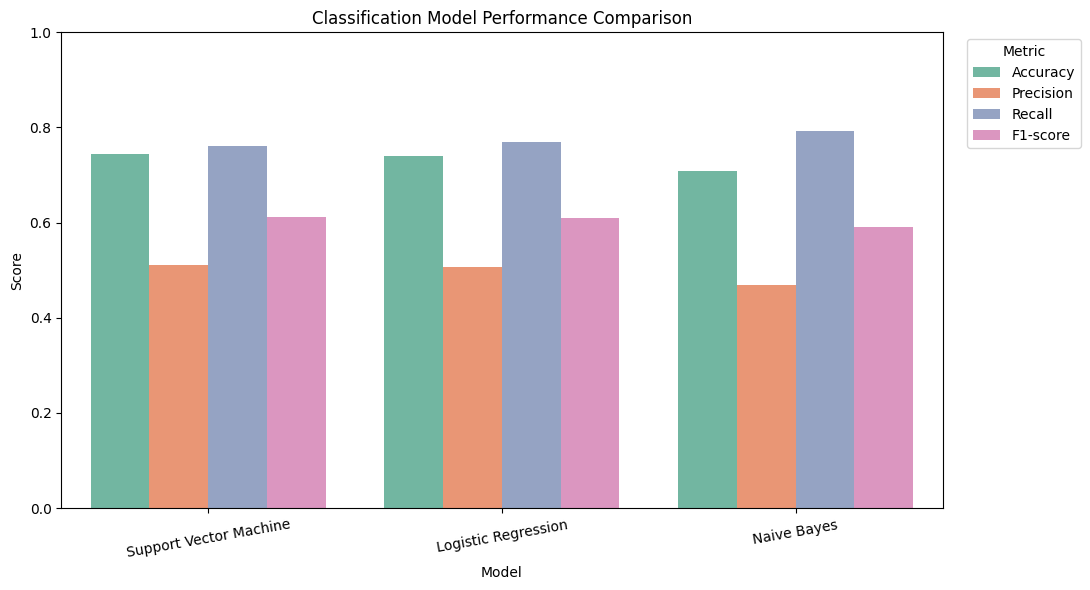

In [30]:
comparison_long = metrics_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


In [31]:
best_model_name = metrics_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 75)
print("BEST MODEL")
print("=" * 75)

print("Selected model:", best_model_name)
print("\nBest-model metrics:")
print(metrics_df.iloc[0])


BEST MODEL
Selected model: Support Vector Machine

Best-model metrics:
Model        Support Vector Machine
Accuracy                   0.744484
Precision                  0.511754
Recall                     0.760753
F1-score                   0.611892
ROC-AUC                    0.819791
Name: 0, dtype: object


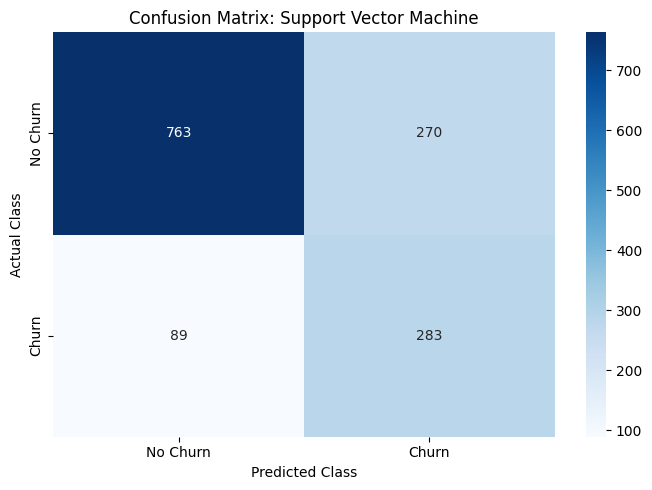


Confusion matrix values:
True negatives : 763
False positives: 270
False negatives: 89
True positives : 283


In [32]:
best_confusion_matrix = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = best_confusion_matrix.ravel()

print("\nConfusion matrix values:")
print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)


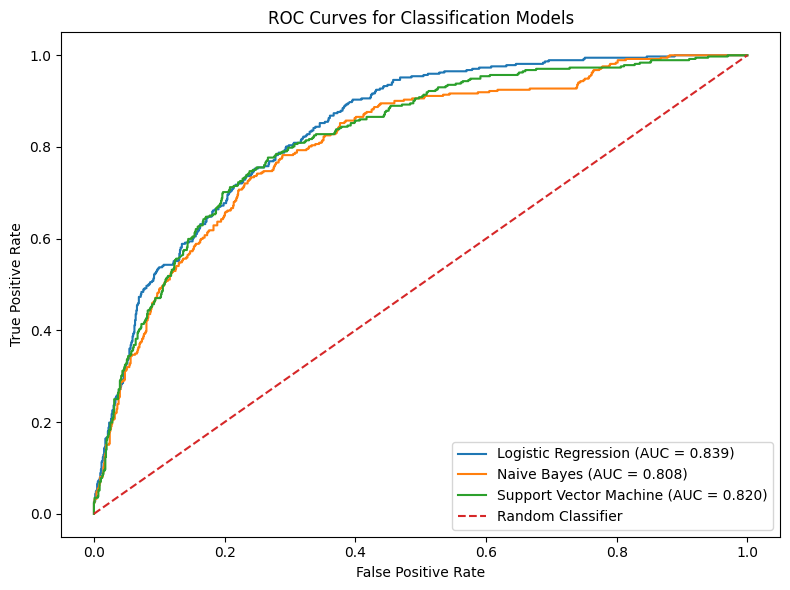

In [33]:
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in trained_models.items():

    probabilities = model_pipeline.predict_proba(X_test)[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    model_auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Summary
Among the three classification models, Support Vector Machine (SVM) achieved the best overall performance and was selected as the final model. It provided the highest balance of accuracy, precision, recall, and F1-score, making it the most effective at correctly identifying customers who are likely to churn while minimizing misclassifications. Therefore, SVM is the most suitable model for this dataset to support focused customer retention strategies.